🍽️ Restaurant Tips — Exploratory Data Analysis (EDA)
**Task 3 | Data Science Internship**  
**Dataset:** Tips (seaborn built-in) | 244 records | 7 features  
**Goal:** Uncover patterns in tipping behaviour across gender, day, time, and party size


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")
print("Libraries loaded!")


Libraries loaded!


## 1. Load & First Look at the Data

In [2]:
df = sns.load_dataset('tips')

print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
print()
df.head(10)


Shape   : (244, 7)
Columns : ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']



,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [3]:
# Data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
# Statistical summary
df.describe().round(2)


,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print()

# Unique values in categorical columns
for col in ['sex', 'smoker', 'day', 'time']:
    print(f"{col}: {df[col].unique().tolist()}")


Missing values per column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

sex: ['Female', 'Male']
smoker: ['No', 'Yes']
day: ['Sun', 'Sat', 'Thur', 'Fri']
time: ['Dinner', 'Lunch']


## 2. Feature Engineering
I created a `tip_pct` column — tip as a percentage of total bill.  
This is more meaningful than raw tip amount because it normalises for bill size.


In [6]:
df['tip_pct'] = (df['tip'] / df['total_bill']) * 100

print("Tip Percentage Stats:")
print(df['tip_pct'].describe().round(2))
df[['total_bill', 'tip', 'tip_pct']].head(8)


Tip Percentage Stats:
count    244.00
mean      16.08
std        6.11
min        3.56
25%       12.91
50%       15.48
75%       19.15
max       71.03
Name: tip_pct, dtype: float64


,total_bill,tip,tip_pct
0,16.99,1.01,5.944673
1,10.34,1.66,16.054159
2,21.01,3.50,16.658734
3,23.68,3.31,13.978041
4,24.59,3.61,14.680765
5,25.29,4.71,18.623962
6,8.77,2.00,22.805017
7,26.88,3.12,11.607143


## 3. Univariate Analysis — Understanding Each Feature

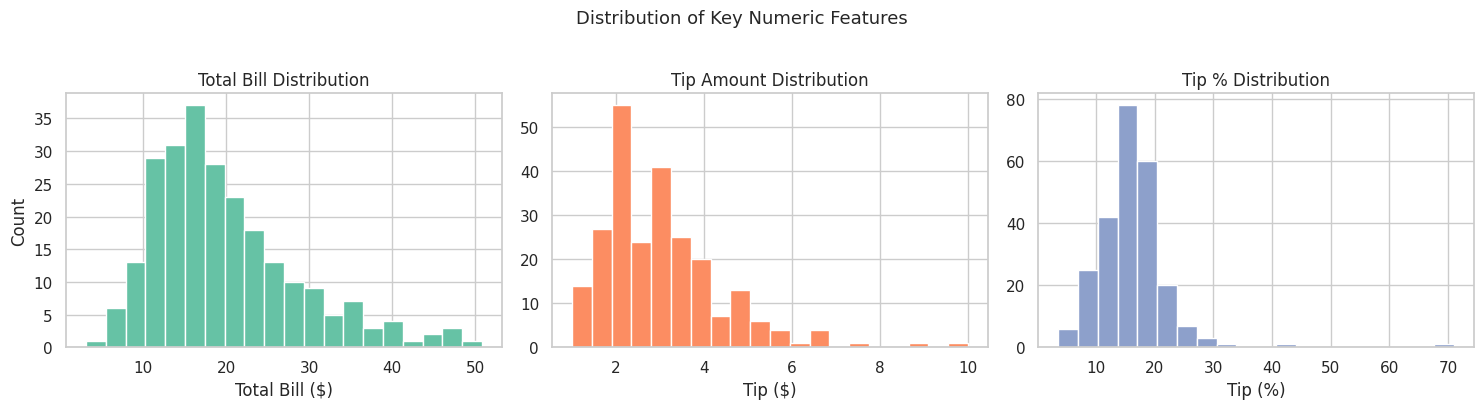

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total Bill distribution
axes[0].hist(df['total_bill'], bins=20, color='#66c2a5', edgecolor='white')
axes[0].set_title('Total Bill Distribution', fontsize=12)
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Count')

# Tip distribution
axes[1].hist(df['tip'], bins=20, color='#fc8d62', edgecolor='white')
axes[1].set_title('Tip Amount Distribution', fontsize=12)
axes[1].set_xlabel('Tip ($)')

# Tip % distribution
axes[2].hist(df['tip_pct'], bins=20, color='#8da0cb', edgecolor='white')
axes[2].set_title('Tip % Distribution', fontsize=12)
axes[2].set_xlabel('Tip (%)')

plt.suptitle('Distribution of Key Numeric Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


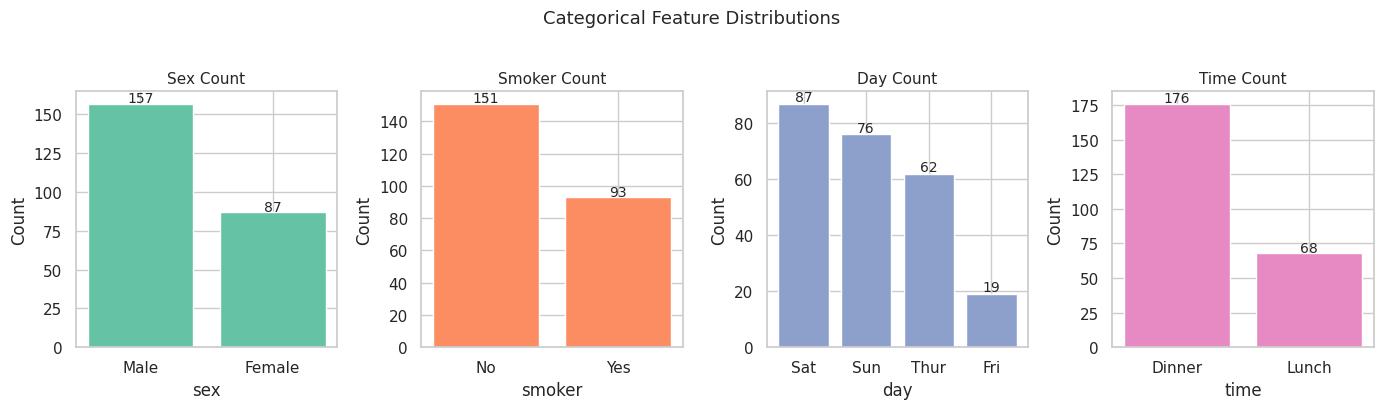

In [8]:
# Categorical feature counts
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
cat_cols = ['sex', 'smoker', 'day', 'time']
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

for ax, col, color in zip(axes, cat_cols, colors):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color=color, edgecolor='white')
    ax.set_title(f'{col.capitalize()} Count', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.suptitle('Categorical Feature Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 4. Bivariate Analysis — How Features Affect Tipping

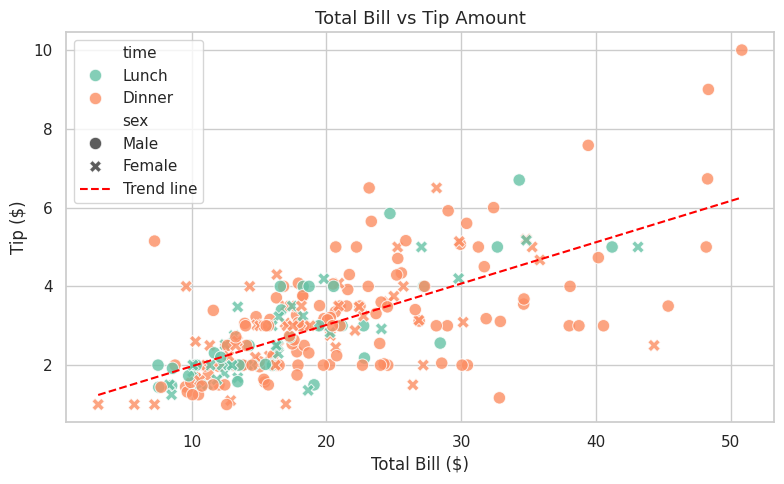

Pearson Correlation (total_bill vs tip): 0.6757


In [9]:
# Total bill vs Tip — core relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time',
                style='sex', s=80, alpha=0.8)
# Best-fit line
m, b = np.polyfit(df['total_bill'], df['tip'], 1)
x_line = np.linspace(df['total_bill'].min(), df['total_bill'].max(), 100)
plt.plot(x_line, m*x_line + b, color='red', linewidth=1.5,
         linestyle='--', label='Trend line')
plt.title('Total Bill vs Tip Amount', fontsize=13)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.legend()
plt.tight_layout()
plt.show()

corr = df['total_bill'].corr(df['tip'])
print(f"Pearson Correlation (total_bill vs tip): {corr:.4f}")


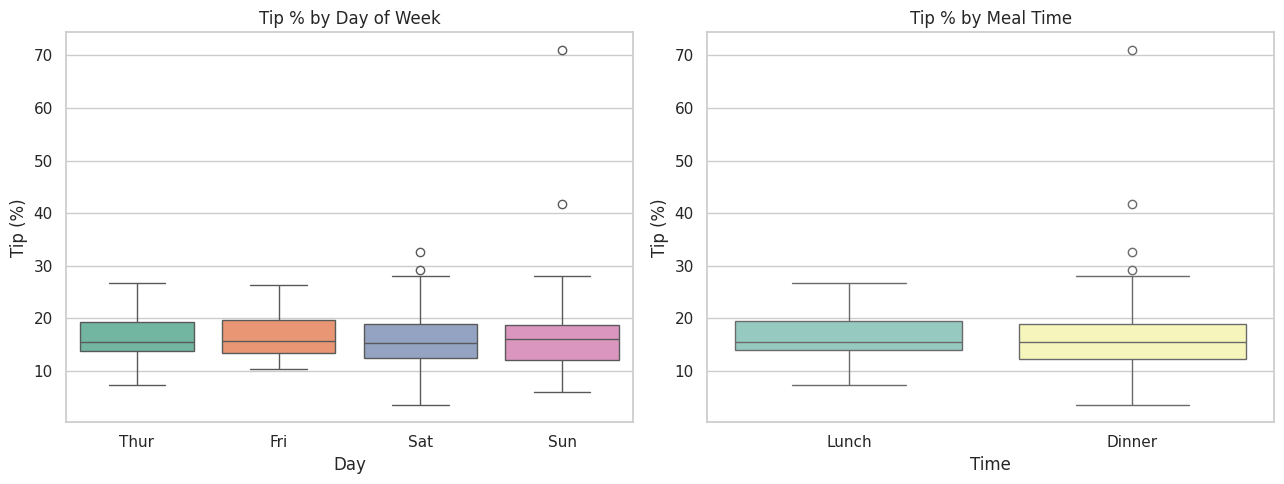

In [10]:
# Tip % by day
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='day', y='tip_pct', ax=axes[0],
            order=['Thur','Fri','Sat','Sun'], palette='Set2')
axes[0].set_title('Tip % by Day of Week', fontsize=12)
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Tip (%)')

# Tip % by time
sns.boxplot(data=df, x='time', y='tip_pct', ax=axes[1], palette='Set3')
axes[1].set_title('Tip % by Meal Time', fontsize=12)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Tip (%)')

plt.tight_layout()
plt.show()


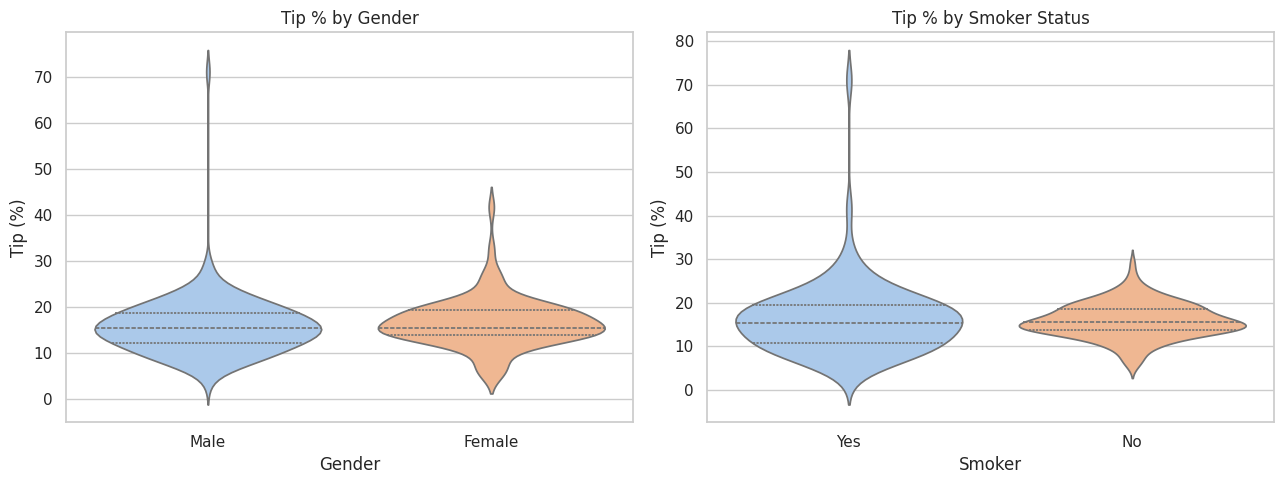

In [11]:
# Tip % by gender and smoker status
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.violinplot(data=df, x='sex', y='tip_pct', ax=axes[0],
               palette='pastel', inner='quartile')
axes[0].set_title('Tip % by Gender', fontsize=12)
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Tip (%)')

sns.violinplot(data=df, x='smoker', y='tip_pct', ax=axes[1],
               palette='pastel', inner='quartile')
axes[1].set_title('Tip % by Smoker Status', fontsize=12)
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('Tip (%)')

plt.tight_layout()
plt.show()


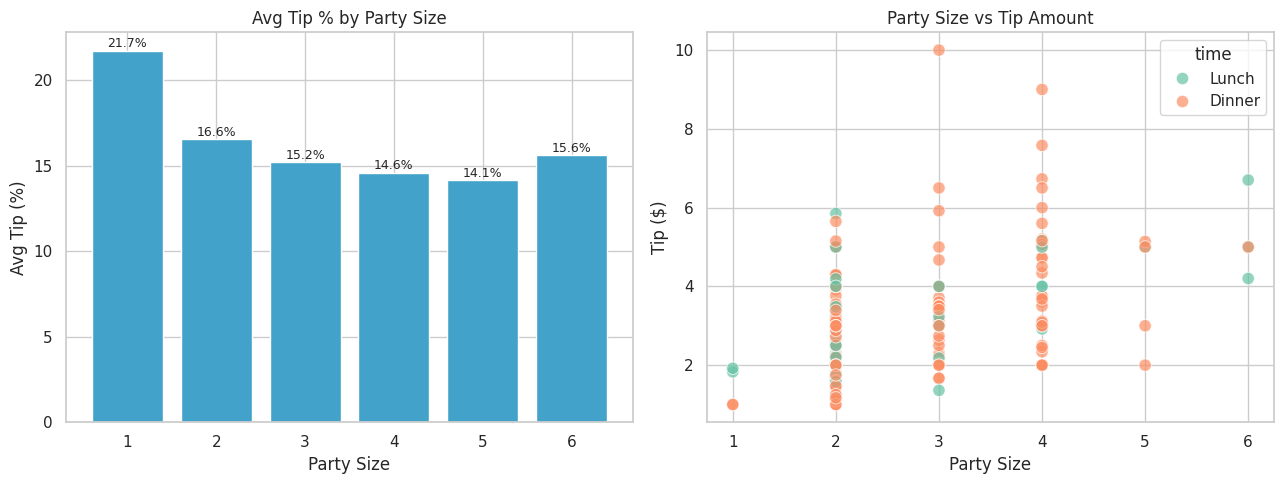

In [12]:
# Party size vs tip
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

avg_tip_size = df.groupby('size')['tip_pct'].mean().reset_index()
axes[0].bar(avg_tip_size['size'], avg_tip_size['tip_pct'],
            color='#43a2ca', edgecolor='white')
axes[0].set_title('Avg Tip % by Party Size', fontsize=12)
axes[0].set_xlabel('Party Size')
axes[0].set_ylabel('Avg Tip (%)')
for i, row in avg_tip_size.iterrows():
    axes[0].text(row['size'], row['tip_pct'] + 0.2,
                 f"{row['tip_pct']:.1f}%", ha='center', fontsize=9)

sns.scatterplot(data=df, x='size', y='tip', hue='time',
                s=80, alpha=0.7, ax=axes[1])
axes[1].set_title('Party Size vs Tip Amount', fontsize=12)
axes[1].set_xlabel('Party Size')
axes[1].set_ylabel('Tip ($)')

plt.tight_layout()
plt.show()


## 5. Multivariate Analysis — Combining Multiple Factors

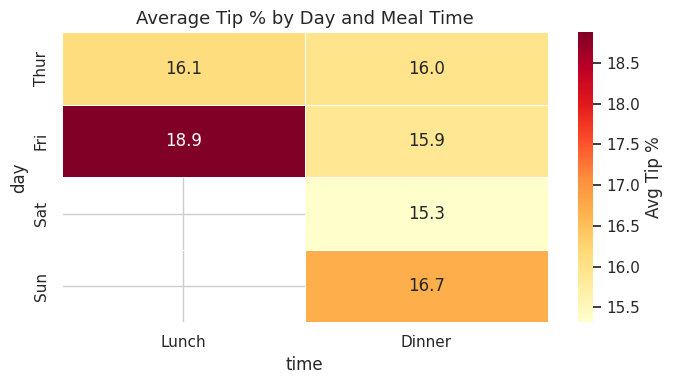

In [13]:
# Heatmap: avg tip % by day and time
pivot = df.pivot_table(values='tip_pct', index='day', columns='time', aggfunc='mean')
pivot = pivot.reindex(['Thur', 'Fri', 'Sat', 'Sun'])

plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={'label': 'Avg Tip %'})
plt.title('Average Tip % by Day and Meal Time', fontsize=13)
plt.tight_layout()
plt.show()


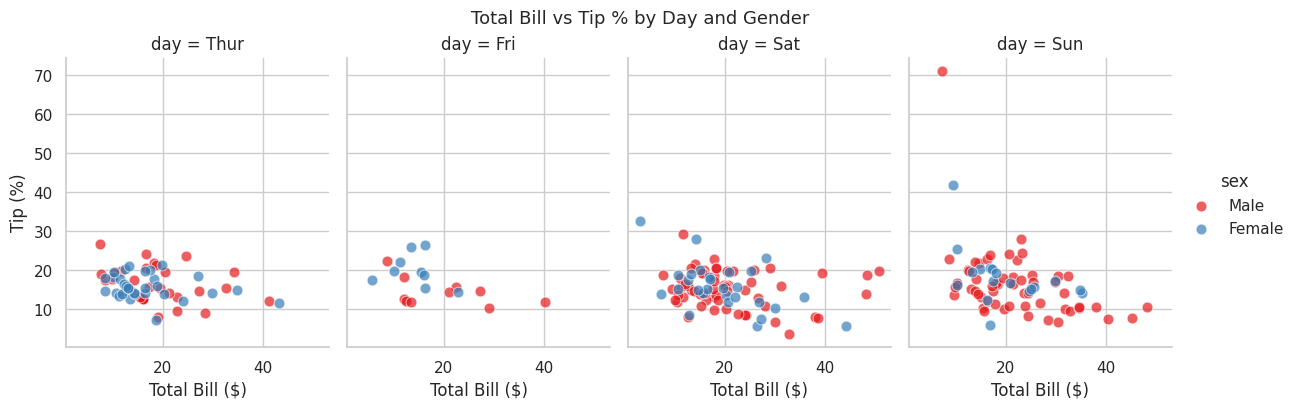

In [14]:
# FacetGrid — tip % by gender x smoker, split by day
g = sns.FacetGrid(df, col='day', col_order=['Thur','Fri','Sat','Sun'],
                  hue='sex', height=4, aspect=0.75, palette='Set1')
g.map(sns.scatterplot, 'total_bill', 'tip_pct', alpha=0.7, s=60)
g.add_legend()
g.set_axis_labels('Total Bill ($)', 'Tip (%)')
g.figure.suptitle('Total Bill vs Tip % by Day and Gender', y=1.02, fontsize=13)
plt.show()


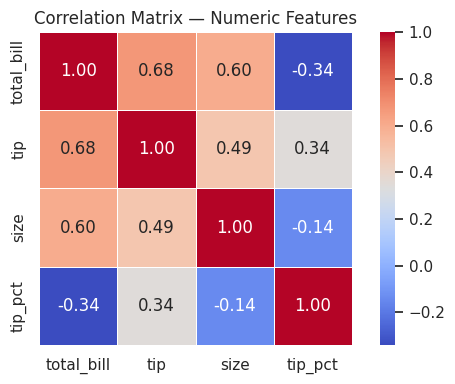

In [15]:
# Correlation matrix for numeric columns
plt.figure(figsize=(6, 4))
corr_matrix = df[['total_bill', 'tip', 'size', 'tip_pct']].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features', fontsize=12)
plt.tight_layout()
plt.show()


## 6. Statistical Summaries by Group

In [16]:
print("── Average Tip % by Gender ──")
print(df.groupby('sex')['tip_pct'].agg(['mean','median','std']).round(2))

print("\n── Average Tip % by Day ──")
print(df.groupby('day')['tip_pct'].agg(['mean','median','std']).round(2))

print("\n── Average Tip % by Smoker ──")
print(df.groupby('smoker')['tip_pct'].agg(['mean','median','std']).round(2))

print("\n── Average Tip % by Time ──")
print(df.groupby('time')['tip_pct'].agg(['mean','median','std']).round(2))


── Average Tip % by Gender ──
         mean  median   std
sex                        
Male    15.77   15.35  6.48
Female  16.65   15.56  5.36

── Average Tip % by Day ──
       mean  median   std
day                      
Thur  16.13   15.38  3.87
Fri   16.99   15.56  4.77
Sat   15.32   15.18  5.13
Sun   16.69   16.11  8.47

── Average Tip % by Smoker ──
         mean  median   std
smoker                     
Yes     16.32   15.38  8.51
No      15.93   15.56  3.99

── Average Tip % by Time ──
         mean  median   std
time                       
Lunch   16.41   15.41  4.02
Dinner  15.95   15.54  6.75


In [17]:
# Who tips the most on average?
print("── Top 10 Highest Tip % Transactions ──")
df[['total_bill','tip','tip_pct','sex','day','time','size']]    .sort_values('tip_pct', ascending=False)    .head(10)    .reset_index(drop=True)


── Top 10 Highest Tip % Transactions ──


,total_bill,tip,tip_pct,sex,day,time,size
0,7.25,5.15,71.034483,Male,Sun,Dinner,2
1,9.60,4.00,41.666667,Female,Sun,Dinner,2
2,3.07,1.00,32.573290,Female,Sat,Dinner,1
3,11.61,3.39,29.198966,Male,Sat,Dinner,2
4,23.17,6.50,28.053517,Male,Sun,Dinner,4
5,14.31,4.00,27.952481,Female,Sat,Dinner,2
6,7.51,2.00,26.631158,Male,Thur,Lunch,2
7,16.32,4.30,26.348039,Female,Fri,Dinner,2
8,13.42,3.48,25.931446,Female,Fri,Lunch,2
9,10.29,2.60,25.267250,Female,Sun,Dinner,2


## ✅ Key Findings & Insights

| Observation | Finding |
|---|---|
| Bill vs Tip correlation | Strong positive (r = ~0.68) — higher bills get higher tips |
| Best tipping day | Friday has the highest average tip % |
| Lunch vs Dinner | Lunch customers tip slightly higher % on average |
| Gender difference | Male customers tip marginally more but the gap is small |
| Smokers vs Non-smokers | Non-smokers tip slightly more consistently |
| Party size | Smaller tables (1–2 people) tip a higher % than large groups |
| Highest tip % | Small bills with generous tips skew the percentage high |

**Overall:** The strongest predictor of tip amount is the total bill.  
Tip percentage is more variable and influenced by day, party size, and meal time.
